In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

root_path = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "utils").exists()), None)
if root_path is None:
    raise FileNotFoundError("Could not locate project root containing 'utils' directory")
sys.path.append(str(root_path))

from utils.helpers import load_data

In [2]:
df = pd.read_excel(f"../data/results/IN1020_2025_CBM_exam_results_big_overview.xlsx", engine="openpyxl")
df.head()

,student_id,total_CBM_score_with_minus_points,total_CBM_score_without_minus_points,total_exam_score_without_CBM_out_of_86_points
0,15001,54,54,65.65
1,15002,16,28,33.88
2,15003,19,39,30.01
3,15005,38,42,57.45
4,15007,43,43,64.82


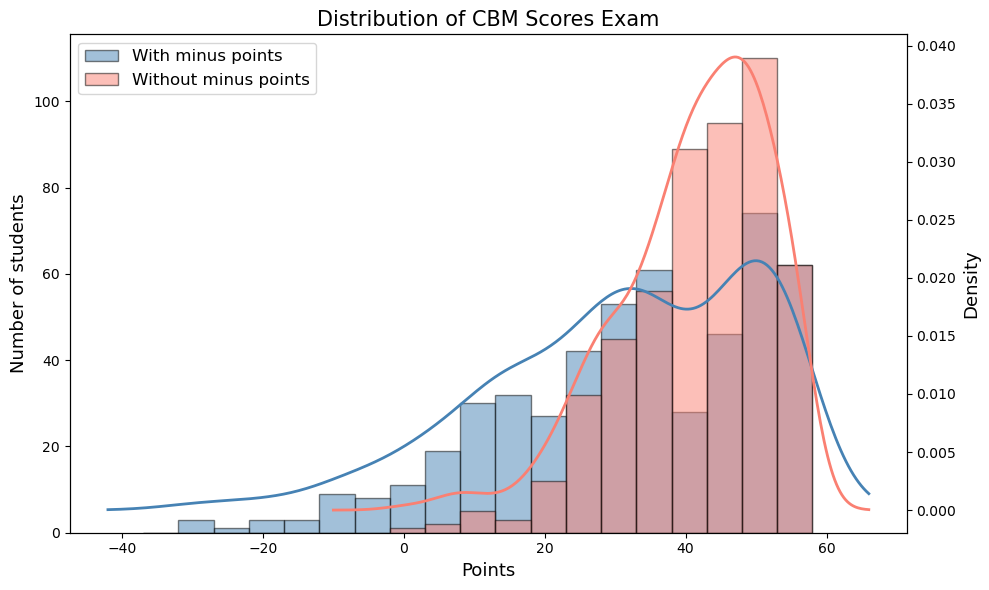

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

bins = np.arange(
    min(df["total_CBM_score_with_minus_points"].min(), df["total_CBM_score_without_minus_points"].min()) - 5,
    max(df["total_CBM_score_with_minus_points"].max(), df["total_CBM_score_without_minus_points"].max()) + 5,
    5
)

ax.hist(df["total_CBM_score_with_minus_points"], bins=bins, alpha=0.5,
        label="With minus points", color="steelblue", edgecolor="black")
ax.hist(df["total_CBM_score_without_minus_points"], bins=bins, alpha=0.5,
        label="Without minus points", color="salmon", edgecolor="black")

# KDE density curves on secondary axis
ax2 = ax.twinx()
for col, color in [("total_CBM_score_with_minus_points", "steelblue"),
                   ("total_CBM_score_without_minus_points", "salmon")]:
    data = df[col].dropna()
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min() - 10, data.max() + 10, 300)
    ax2.plot(x_range, kde(x_range), color=color, linewidth=2)
ax2.set_ylabel("Density", fontsize=13)

ax.set_xlabel("Points", fontsize=13)
ax.set_ylabel("Number of students", fontsize=13)
ax.set_title("Distribution of CBM Scores Exam", fontsize=15)
ax.legend(fontsize=12)
plt.tight_layout()

output_dir = root_path / "analysis" / "CBM" / "2025" / "Exam" / "output" / "output_total_scores"
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / "Distribution_of_CBM_Scores_Exam.png")

plt.show()

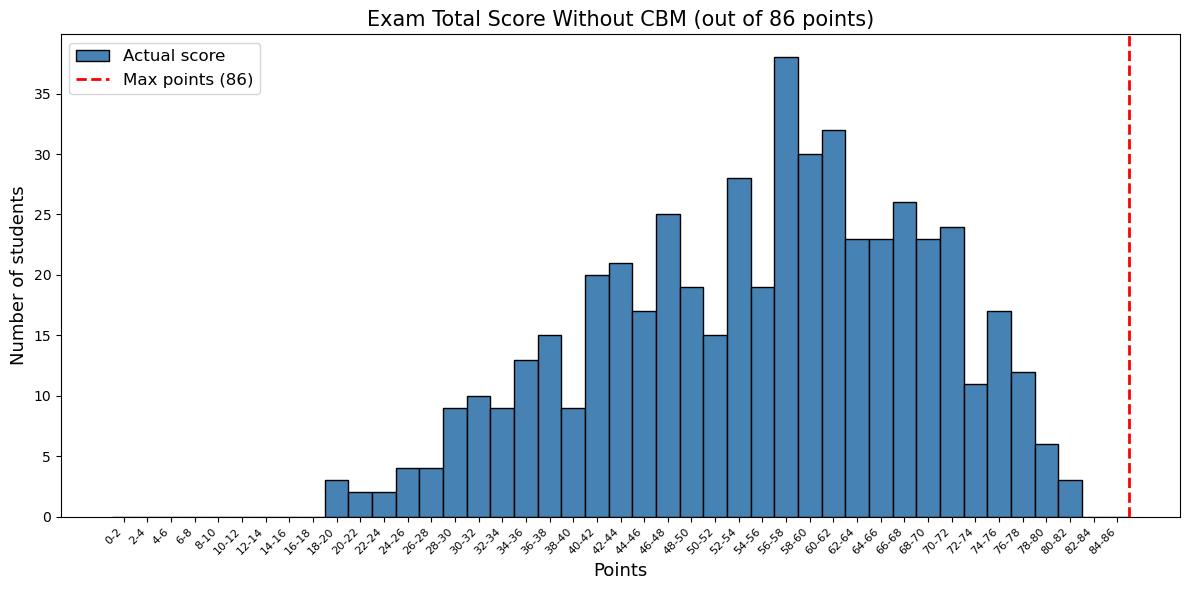

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

bin_width = 2
bins = np.arange(0, 88, bin_width)
counts, bin_edges, patches = ax.hist(
    df["total_exam_score_without_CBM_out_of_86_points"], bins=bins,
    color="steelblue", edgecolor="black", label="Actual score"
)

# Set ticks at the center of each bin
bin_centers = bin_edges[:-1] + bin_width / 2
ax.set_xticks(bin_centers)
ax.set_xticklabels([f"{int(edge)}-{int(edge + bin_width)}" for edge in bin_edges[:-1]], rotation=45, ha="right", fontsize=8)

ax.axvline(x=86, color="red", linestyle="--", linewidth=2, label="Max points (86)")

ax.set_xlabel("Points", fontsize=13)
ax.set_ylabel("Number of students", fontsize=13)
ax.set_title("Exam Total Score Without CBM (out of 86 points)", fontsize=15)
ax.legend(fontsize=12)
plt.tight_layout()

output_dir = root_path / "analysis" / "CBM" / "2025" / "Exam" / "output" / "output_total_scores"
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / "Exam_Total_Score_Without_CBM_(out_of_86_points).png")

plt.show()